## HM-LS 90% Util with 1MB writes

In [47]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

import seaborn as sns

def custom_grouping(index):
    return index // 1000

names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
names_latency=['time', 'latency', 'op2', 'write_size', 'op3']

In [60]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'fast2026/lsdm/lsdm-util/90Util/1MB/8TB/90-10-LBA/45GB/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)

df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

In [61]:
# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576 #1MB
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]

/tmp/ipykernel_3364811/3920337363.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.

46079


In [62]:
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped.describe())
print(df_grouped.info())

           index  data_written_bytes  cumulative_gb
count  650.00000          650.000000     650.000000
mean   324.50000           70.892308      28.024656
std    187.78312           59.480189      12.607822
min      0.00000            0.000000       0.151828
25%    162.25000           29.817369      18.497517
50%    324.50000           58.101518      31.439874
75%    486.75000           85.389849      38.190078
max    649.00000          236.404751      45.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               650 non-null    int64  
 1   data_written_bytes  650 non-null    float64
 2   cumulative_gb       650 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 15.4 KB
None


In [63]:
data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + ' MB/s'
avg_bw_str2 = str(round(average_mode2, 2)) + ' MB/s'

Average1: 47
Average2: 186


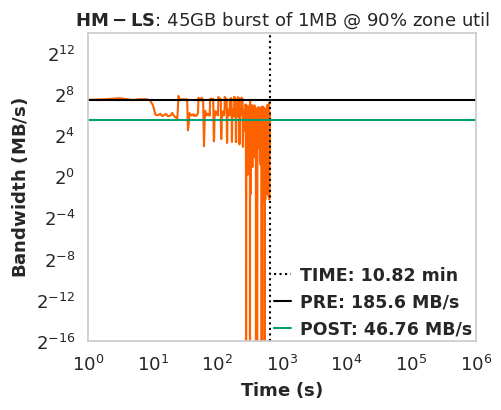

In [64]:
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped, color='#FE6100')
plt.title(r"$\bf{HM-LS}$: 45GB burst of 1MB @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='#009E73', linestyle='-', label='POST: ' + avg_bw_str1)
# plt.legend(loc='lower right', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
#            shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13, markerscale=0.1)
plt.legend(
    loc='lower right',
    bbox_to_anchor=(1.0, 0.0),
    prop={'size': 12.5, 'weight': 'semibold'},
    borderaxespad=0.0,              # no padding between axes and legend box
    borderpad=0.2,                  # minimal padding inside legend frame
    frameon=False,
    fancybox=False,
    shadow=False,
    framealpha=0.9,
    edgecolor='lightgray',
    fontsize=12.5,
    markerscale=0.7,        # scales down marker size
    handlelength=1,         # length of line in legend
    handletextpad=0.5       # spacing between line and text
)
plt.savefig('fig/fast2026/1M_90Util_HM-LS_BW.pdf', bbox_inches='tight',dpi=500)
plt.show()

### HM-LS 90% Util, 1MB Uniform Random Writes

In [71]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'fast2026/lsdm/90Util/1MB/8TB/uniform/45GB/round2/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)

df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576 #1MB
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped.describe())
print(df_grouped.info())

/tmp/ipykernel_3364811/1770814560.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.

46079
             index  data_written_bytes  cumulative_gb
count  3470.000000         3470.000000    3470.000000
mean   1734.500000           13.279539      35.975505
std    1001.847044           36.603070       8.318411
min       0.000000            0.000000       0.151609
25%     867.250000            1.119774      34.191052
50%    1734.500000            1.413499      37.686997
75%    2601.750000            2.976776      41.418080
max    3469.000000          245.464523      45.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3470 entries, 0 to 3469
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               3470 non-null   int64  
 1   data_written_bytes  3470 non-null   float64
 2   cumulative_gb       3470 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 81.5 KB
None


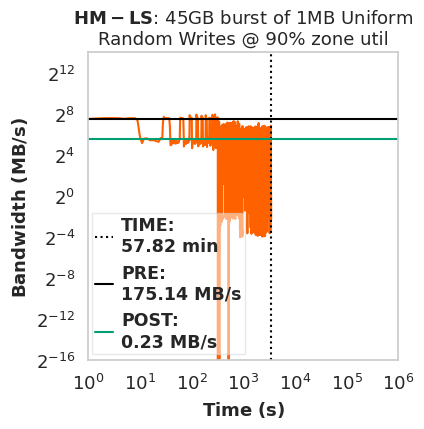

In [77]:
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(4, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped, color='#FE6100')
plt.title(r"$\bf{HM-LS}$: 45GB burst of 1MB Uniform" "\n" "Random Writes @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME:\n' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE:\n' + avg_bw_str2)
plt.axhline(y=average_mode1, color='#009E73', linestyle='-', label='POST:\n' + avg_bw_str1)
# plt.legend(loc='lower left', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
#            shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13, markerscale=0.1)
plt.legend(
    loc='lower left',
    bbox_to_anchor=(0.0, 0.01),
    prop={'size': 12.5, 'weight': 'semibold'},
    borderaxespad=0.2,              # no padding between axes and legend box
    borderpad=0.2,                  # minimal padding inside legend frame
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.5,
    edgecolor='lightgray',
    fontsize=12.5,
    markerscale=0.7,        # scales down marker size
    handlelength=1,         # length of line in legend
    handletextpad=0.5       # spacing between line and text
)
plt.savefig('fig/fast2026/1M_90Util_Uniform_HM-LS_BW.pdf', bbox_inches='tight',dpi=500)
plt.show()

### HM-LS 90% Util, 4KB 90-10 LBA Random Writes

In [67]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'fast2026/lsdm/4K/90-10-LBA/90Util/run2/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)

df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine time range
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Pre-compute all values vectorized
df_vec = df.copy()
df_vec['duration'] = df_vec['duration'].astype(float)
df_vec['start'] = df_vec['submission_time'].astype(int)
df_vec['end'] = df_vec['start'] + np.floor(df_vec['duration']).astype(int)

payload = 4096  # 4KB
df_vec['write_rate_per_ms'] = payload / np.maximum(df_vec['duration'], 1.0)
df_vec['floor_duration'] = np.floor(df_vec['duration']).astype(int)
df_vec['residue'] = payload - df_vec['write_rate_per_ms'] * df_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)

##################################

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_grouped_vec.reset_index(inplace=True)
df_grouped_vec['cumulative_gb'] = df_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped_vec['data_written_bytes'] = df_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped_vec.describe())
print(df_grouped_vec.info())

####################

data_array_vec = df_grouped_vec['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array_vec)
# Get the cluster centers
cluster_centers_vec = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers_vec.sort()
# Calculate the average of each mode
average_mode1_vec = cluster_centers_vec[0]
average_mode2_vec = cluster_centers_vec[1]
print("Average1: " + str(round(average_mode1_vec, )))
print("Average2: " + str(round(average_mode2_vec, )))
avg_bw_str1 = str(round(average_mode1_vec, 2)) + ' MB/s'
avg_bw_str2 = str(round(average_mode2_vec, 2)) + ' MB/s'

             index  data_written_bytes  cumulative_gb
count  1857.000000         1857.000000    1857.000000
mean    928.000000            2.757135       2.778088
std     536.214043           13.814532       1.333407
min       0.000000            0.000000       0.040176
25%     464.000000            0.046855       1.506765
50%     928.000000            0.047665       2.841485
75%    1392.000000            0.048279       3.845278
max    1856.000000          177.698510       5.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1857 entries, 0 to 1856
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               1857 non-null   int64  
 1   data_written_bytes  1857 non-null   float64
 2   cumulative_gb       1857 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 43.7 KB
None
Average1: 2
Average2: 147


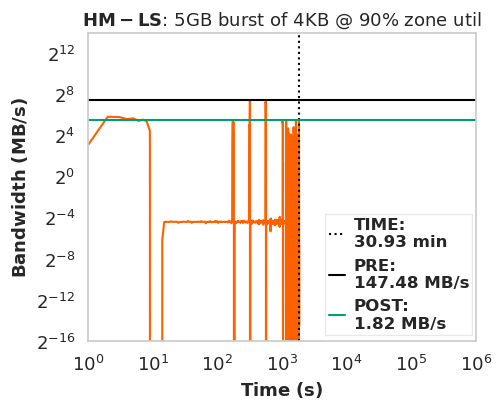

In [68]:
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped_vec, color='#FE6100')
plt.title(r"$\bf{HM-LS}$: 5GB burst of 4KB @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped_vec.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME:\n' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE:\n' + avg_bw_str2)
plt.axhline(y=average_mode1, color='#009E73', linestyle='-', label='POST:\n' + avg_bw_str1)
# plt.legend(loc='lower right', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
#            shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13, markerscale=0.1)
plt.legend(
    loc='lower right',
    bbox_to_anchor=(1.0, 0.01),
    prop={'size': 12, 'weight': 'semibold'},
    borderaxespad=0.2,              # no padding between axes and legend box
    borderpad=0.2,                  # minimal padding inside legend frame
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.5,
    edgecolor='lightgray',
    fontsize=12,
    markerscale=0.7,        # scales down marker size
    handlelength=1,         # length of line in legend
    handletextpad=0.5       # spacing between line and text
)
plt.savefig('fig/fast2026/4KB_90Util_90-10_LBA_HM-LS_BW.pdf', bbox_inches='tight',dpi=500)
plt.show()

### HM-LS 90% Util, 4KB Uniform Random Writes

```python

In [78]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'fast2026/lsdm/lsdm-util/90Util/4KB/8TB/uniform-random/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)

df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine time range
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Pre-compute all values vectorized
df_vec = df.copy()
df_vec['duration'] = df_vec['duration'].astype(float)
df_vec['start'] = df_vec['submission_time'].astype(int)
df_vec['end'] = df_vec['start'] + np.floor(df_vec['duration']).astype(int)

payload = 4096  # 4KB
df_vec['write_rate_per_ms'] = payload / np.maximum(df_vec['duration'], 1.0)
df_vec['floor_duration'] = np.floor(df_vec['duration']).astype(int)
df_vec['residue'] = payload - df_vec['write_rate_per_ms'] * df_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)

##################################

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_grouped_vec.reset_index(inplace=True)
df_grouped_vec['cumulative_gb'] = df_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped_vec['data_written_bytes'] = df_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped_vec.describe())
print(df_grouped_vec.info())

####################

data_array_vec = df_grouped_vec['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array_vec)
# Get the cluster centers
cluster_centers_vec = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers_vec.sort()
# Calculate the average of each mode
average_mode1_vec = cluster_centers_vec[0]
average_mode2_vec = cluster_centers_vec[1]
print("Average1: " + str(round(average_mode1_vec, )))
print("Average2: " + str(round(average_mode2_vec, )))
avg_bw_str1 = str(round(average_mode1_vec, 2)) + ' MB/s'
avg_bw_str2 = str(round(average_mode2_vec, 2)) + ' MB/s'

             index  data_written_bytes  cumulative_gb
count  5476.000000         5476.000000    5476.000000
mean   2737.500000            0.934989       2.728459
std    1580.929368           11.476394       1.318113
min       0.000000            0.000000       0.029500
25%    1368.750000            0.046720       2.150071
50%    2737.500000            0.047179       2.211944
75%    4106.250000            0.047663       4.012100
max    5475.000000          194.000010       5.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5476 entries, 0 to 5475
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               5476 non-null   int64  
 1   data_written_bytes  5476 non-null   float64
 2   cumulative_gb       5476 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 128.5 KB
None
Average1: 0
Average2: 175


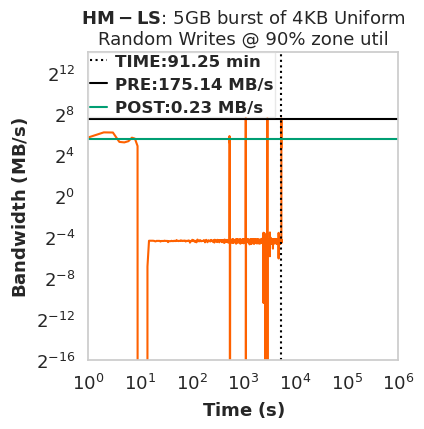

In [ ]:
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(4, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped_vec, color='#FE6100')
plt.title(r"$\bf{HM-LS}$: 5GB burst of 4KB Uniform" "\n" "Random Writes @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped_vec.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME:' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE:' + avg_bw_str2)
plt.axhline(y=average_mode1, color='#009E73', linestyle='-', label='POST:' + avg_bw_str1)
# plt.legend(loc='lower right', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
#            shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13, markerscale=0.1)
plt.legend(
    loc='upper left',
    bbox_to_anchor=(0, 1),
    prop={'size': 12, 'weight': 'semibold'},
    borderaxespad=0.1,              # no padding between axes and legend box
    borderpad=0.1,                  # minimal padding inside legend frame
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.5,
    edgecolor='lightgray',
    fontsize=12,
    markerscale=0.7,        # scales down marker size
    handlelength=1,         # length of line in legend
    handletextpad=0.5       # spacing between line and text
)
plt.savefig('fig/fast2026/4KB_90Util_Uniform_HM-LS_BW.pdf', bbox_inches='tight',dpi=500)
plt.show()